In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruchikakumbhar/calories-burnt-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'calories-burnt-prediction' dataset.
Path to dataset files: /kaggle/input/calories-burnt-prediction


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
import os

# List the contents of the downloaded directory to find the correct CSV file
print("Files in the downloaded directory:")
for file in os.listdir(path):
    print(file)

# Correcting the filepath based on the `os.listdir(path)` output
filepath = os.path.join(path, "calories.csv")

# Try reading the CSV file
try:
    df = pd.read_csv(filepath)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{filepath}' was not found. Please check the file name and path.")
    print("Common issue: The dataset might be inside a subfolder or have a different name.")
    print("Please examine the output of 'os.listdir(path)' above to find the correct file path.")

Files in the downloaded directory:
calories.csv
Dataset loaded successfully.


In [4]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
df.shape

(15000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [7]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [8]:
df.skew(numeric_only=True)

,0
User_ID,0.004788
Age,0.473383
Height,-0.006190
Weight,0.226725
Duration,0.004751
Heart_Rate,-0.010704
Body_Temp,-0.994382
Calories,0.505371


### Correlation Matrix
Let's visualize the correlation between numerical features using a heatmap.

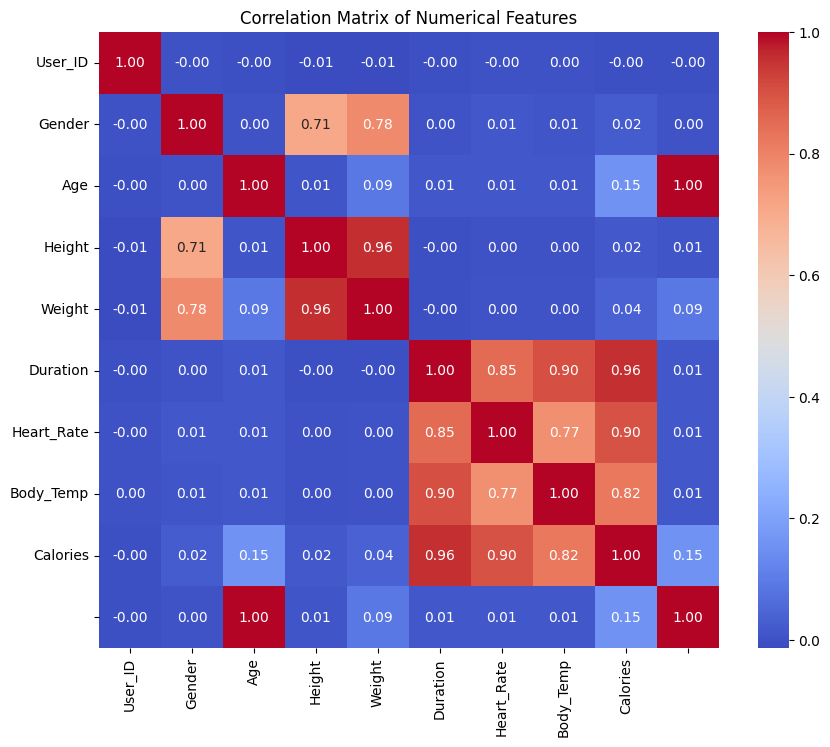

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Distribution of Numerical Features
Let's examine the distribution of each numerical feature.

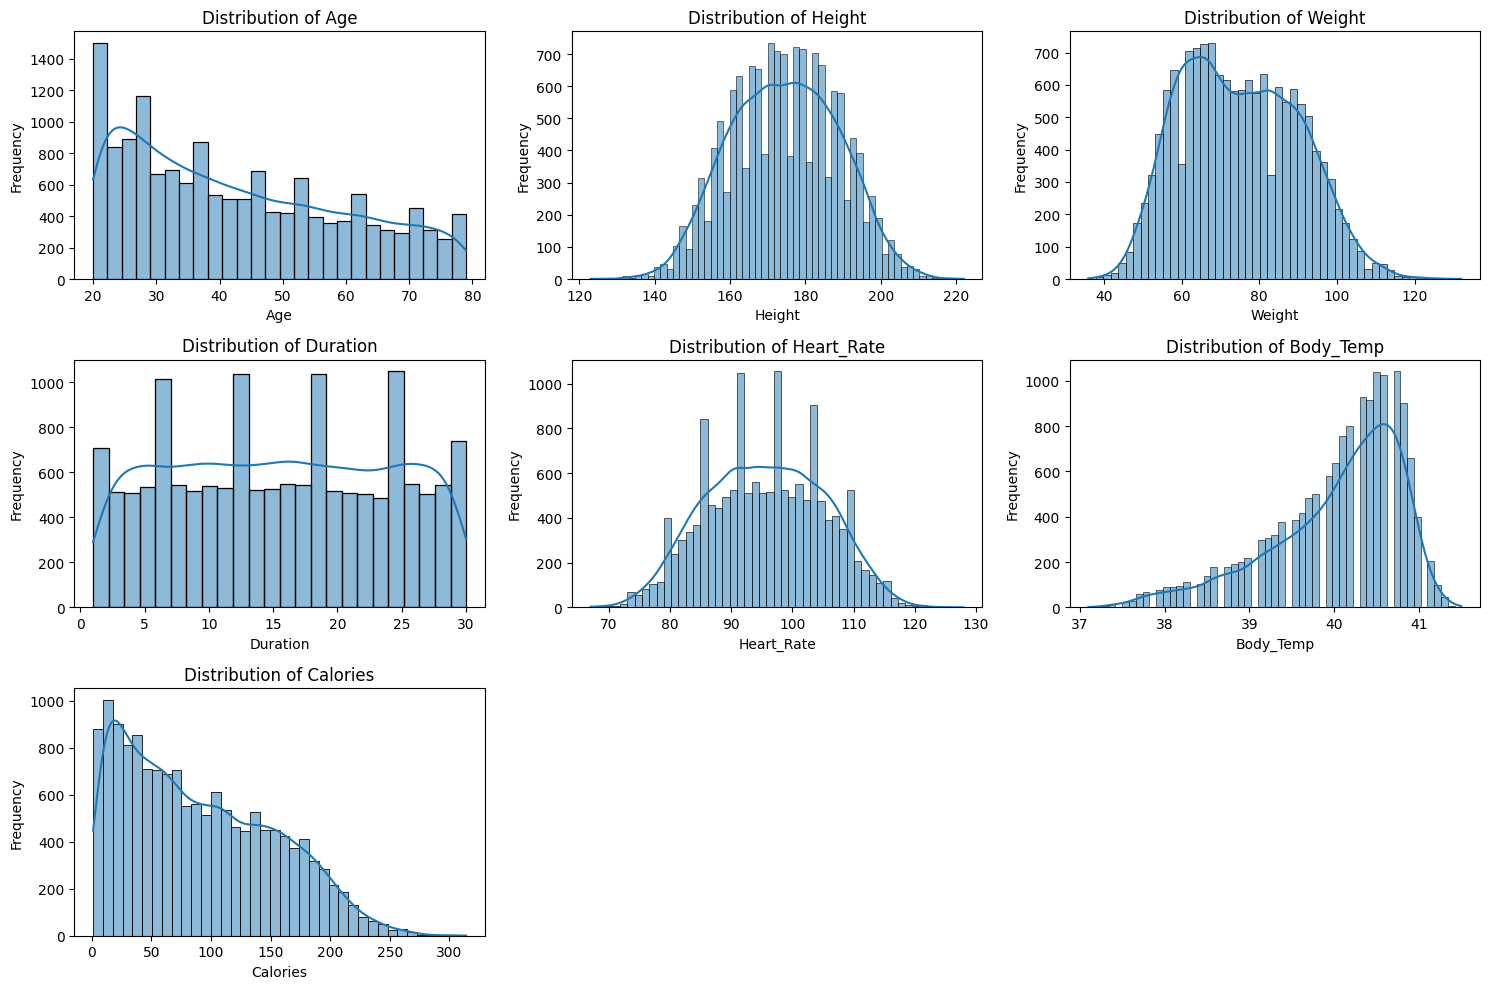

In [29]:
numerical_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [9]:
#label encoding
df["Gender"]=df["Gender"].map({"male":1,"female":0})

In [10]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0


<Axes: xlabel='Calories', ylabel='Count'>

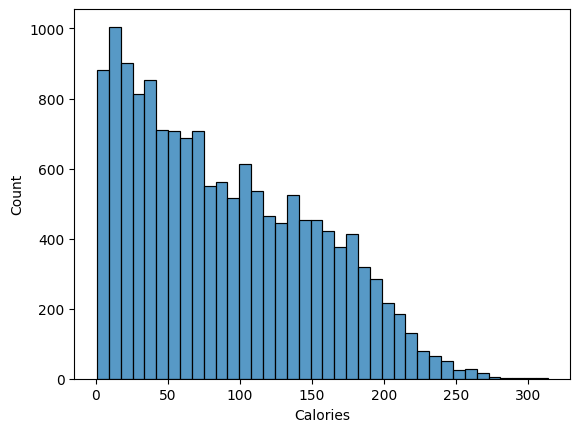

In [11]:
sns.histplot(df["Calories"])

<Axes: xlabel='Calories', ylabel='Count'>

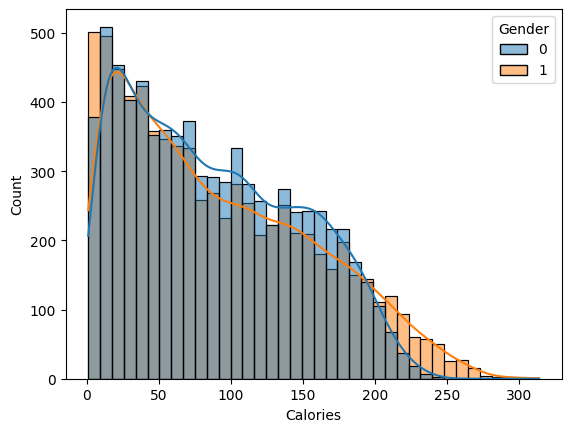

In [12]:
sns.histplot(data=df, x="Calories", kde=True, hue="Gender")

In [13]:
#standar scaler  ->for distance based algos
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[""]=scaler.fit_transform(df[["Age"]])

In [14]:
x=df.drop(columns=["Calories"],)
y=df["Calories"]
#

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
#hyperparameter tunning
from sklearn.model_selection import RandomizedSearchCV
# estimator = jo model use karne wale h
#param distribution  me estimator ke features aate h
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[2,5,10],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}


In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
random = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1)


In [19]:
random.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [2, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=2)

In [20]:
model=random.best_estimator_

In [21]:
random.best_score_


np.float64(0.9958125984880267)

In [22]:
# building random forest model
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                      n_estimators=200)
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                      n_estimators=200)

In [23]:
# train
y_pred=model.predict(x_train) #seen values

In [24]:
# prediction
y_pred=model.predict(x_test) #unseen values
y_pred

array([169.27146518, 196.42481686,  53.31852448, ..., 120.30528802,
        19.52690036, 212.86478825])

In [25]:
# evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE: 2.3200038717915668
MSE: 12.14700449203985
RMSE: 3.485255297971707


In [26]:
r2_score(y_test,y_pred)

0.9969901803499357

In [27]:
r2_score(y_train,model.predict(x_train))

0.9982781886129908

In [30]:
import joblib
joblib.dump(model,"calories_burnt.joblib")


['calories_burnt.joblib']